# Lecture 3: Network Analysis

In our previous sessions, we've learned to create and annotate gene coexpression networks with data from public repositories. Today, we are building upon that foundation by investigating network motifs and applying machine learning techniques to our network data.

Our objectives for this lecture include two major topics: **Network Motifs and Modules**, and **Machine Learning and Networks**:

## Network Motifs and Modules

We will dive deeper into the structure of networks, with a focus on common patterns of interactions and their significance. This includes:

- **Understanding Network Motifs**: Familiarize yourself with the concept of network motifs. Learn how these recurrent and statistically significant sub-graphs or patterns are a key feature of many complex networks.

- **Identifying Network Motifs**: Explore the E. coli transcriptional regulatory network example to see how network motifs help provide mechanistic understanding to the regulation of gene expression.

- **Exploring Modules in Networks**: Understand the concept of modules or communities in networks - highly interconnected groups of nodes. Learn the role they play in various biological phenomena.

- **Detecting Modules in Networks**: Learn how to detect and analyze modules within a network. Understand the importance of this modular structure in complex biological networks.

---

In [1]:
# Import required libraries, drives, etc.

import numpy as np              # a Python library for numerical operations.
import pandas as pd             # a library for data manipulation and analysis.
import matplotlib.pyplot as plt # a 2D plotting library to create static, animated, and interactive visualizations.
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

import seaborn as sns           # a Python data visualization library based on matplotlib, for better aesthetic and informative statistical graphics.

import collections              # for high-performance container datatypes.

# Setting Matplotlib to use inline plotting.
# This means the output of plotting commands is displayed inline within frontends like the Jupyter notebook, directly below the code cell that produced it.
%matplotlib inline

# Allowing multiple outputs from the same cell, rather than just the last one run.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from IPython.display import HTML
from IPython.display import Image

# Accessing the output module in Google Colab.
#from google.colab import output
#output.enable_custom_widget_manager() # Enabling custom widget manager for more advanced outputs.

import networkx as nx           # a Python package for the creation, manipulation, and study of the structure, dynamics, and functions of complex networks.

## Directed Graphs

In the realm of network science, it is essential to understand that networks (or graphs) can be categorized into two primary types: **undirected** and **directed**. So far, we've been mostly dealing with undirected graphs where the relationships (edges) between nodes are bidirectional, implying a symmetric relationship. In an undirected graph, if node A is connected to node B, node B is also connected to node A. 

However, many real-world systems involve asymmetric relationships, which are best represented as **directed graphs**. In a directed graph (also known as a **digraph**), edges have a direction. That is, if there's an edge from node A to node B, it doesn't necessarily mean that there's an edge from node B to node A.

Let's illustrate this concept with a simple visualization.

<Figure size 1000x500 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'directed network')

<Axes: >

Text(0.5, 1.0, 'undirected network')

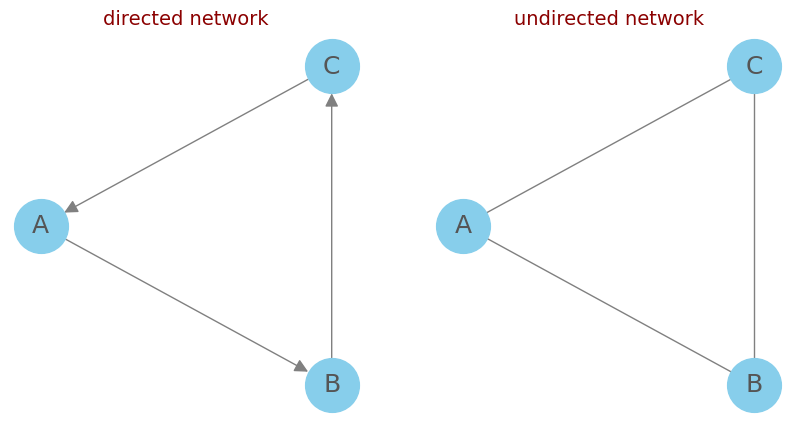

In [2]:
# Create a directed graph
G_directed = nx.DiGraph()
G_directed.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'A')])

# Create an undirected graph
G_undirected = nx.Graph()
G_undirected.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'A')])

plt.figure(figsize=(10, 5))

# Plot the directed graph
plt.subplot(121)
nx.draw_shell(G_directed, with_labels=True, arrows=True, font_color='#555555', node_color='skyblue', node_size=1500, arrowsize=20, font_size=18, edge_color='gray')
plt.title('directed network', size=14, color='darkred')

# Plot the undirected graph
plt.subplot(122)
nx.draw_shell(G_undirected, with_labels=True, font_color='#555555',node_color='skyblue', node_size=1500, font_size=18, edge_color='gray')
plt.title('undirected network', size=14, color='darkred')


## Network Statistics and Properties: Directed vs. Undirected Graphs

When we transform a directed graph into an undirected graph, the way we calculate and interpret graph properties changes significantly.
ce
- **Degree Distribution**: In a directed graph, we distinguish between *in-degree* (number of incoming edges) and *out-degree* (number of outgoing edges) for each node. In contrast, for an undirected graph, we simply talk about the *degree* of a node (number of connected edges).

- **Paths and Connectivity**: In a directed graph, the path from node A to node B might not be the same as the path from node B to node A. In an undirected graph, the path is always symmetrical. Similarly, a directed graph could be strongly connected (there's a directed path between every pair of nodes) or weakly connected (replacing all directed edges with undirected edges results in a connected graph).

- **Centrality Measures**: For directed graphs, centrality measures (degree, closeness, betweenness, eigenvector) will also take into account the direction of the edges, which may give different results compared to an undirected graph.

Let's construct a slightly more complex network consisting of intertwined network motifs, and compare it with its undirected counterpart. The network will consist of 3 nodes motifs (Feed-Forward Loop and Bi-Fan) with some shared nodes.

In the below code, we first create a directed graph consisting of the network motifs, then we create an undirected version of the same graph. We then compute some basic network properties that highlight the differences between the two.



Keep in mind that for some graph properties to be calculated, the graph needs to be connected. The diameter and average shortest path length, for instance, are only defined for connected graphs. As such, we assume that the graph we're working with is connected.

<Figure size 1200x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'directed network')

<Axes: >

Text(0.5, 1.0, 'undirected network')

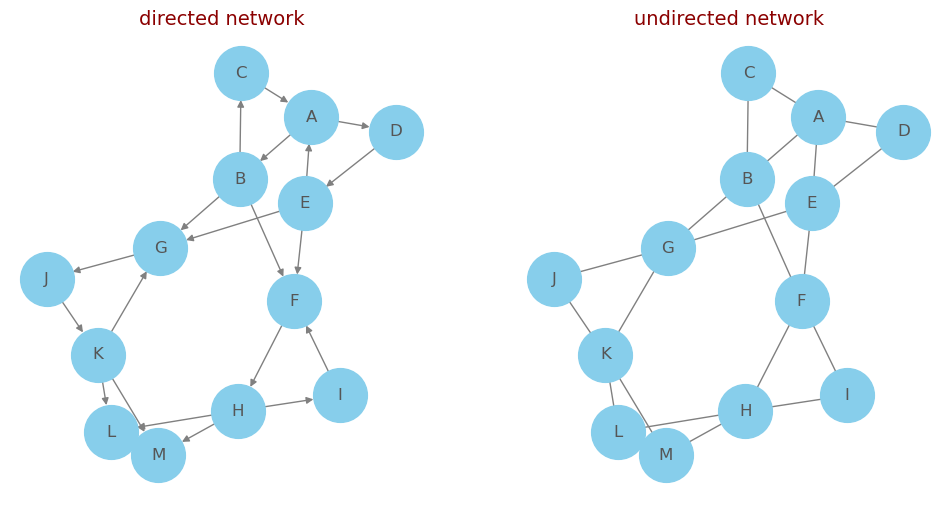

Directed graph:
Average degree:  3.076923076923077
Graph is not strongly connected.
Average clustering coefficient:  0.20512820512820512
Betweenness centrality:  {'A': 0.13636363636363635, 'B': 0.14393939393939395, 'C': 0.022727272727272728, 'D': 0.022727272727272728, 'E': 0.08333333333333334, 'F': 0.17424242424242425, 'G': 0.08333333333333334, 'H': 0.15151515151515152, 'I': 0.007575757575757576, 'J': 0.06060606060606061, 'K': 0.03787878787878788, 'L': 0.0, 'M': 0.0}

Undirected graph:
Average degree:  3.076923076923077
Average shortest path length:  2.2051282051282053
Average clustering coefficient:  0.41025641025641024
Betweenness centrality:  {'A': 0.050505050505050504, 'B': 0.2159090909090909, 'C': 0.0, 'D': 0.0, 'E': 0.2159090909090909, 'F': 0.26262626262626265, 'G': 0.26262626262626265, 'H': 0.17424242424242425, 'I': 0.0, 'J': 0.0, 'K': 0.17424242424242425, 'L': 0.03409090909090909, 'M': 0.03409090909090909}


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Define our directed graph
G_directed = nx.DiGraph()

# 1st Feed-Forward Loop motif
G_directed.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'A')])

# 1st Feed-Back Loop motif
G_directed.add_edges_from([('A', 'D'), ('D', 'E'), ('E', 'A')])

# 1st Bi-Fan motif
G_directed.add_edges_from([('B', 'F'), ('B', 'G'), ('E', 'F'), ('E', 'G')])

# 2nd Feed-Forward Loop motif
G_directed.add_edges_from([('F', 'H'), ('H', 'I'), ('I', 'F')])

# 2nd Feed-Back Loop motif
G_directed.add_edges_from([('G', 'J'), ('J', 'K'), ('K', 'G')])

# 2nd Bi-Fan motif
G_directed.add_edges_from([('H', 'L'), ('H', 'M'), ('K', 'L'), ('K', 'M')])

# Create the undirected version
G_undirected = G_directed.to_undirected()

# Compute a layout for the undirected graph
pos = nx.spring_layout(G_undirected)

# Now use this layout to draw both graphs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
nx.draw(G_directed, pos, with_labels=True, node_color='skyblue',edge_color='grey', node_size=1500, font_color='#555555')
plt.title('directed network', size=14, color='darkred')

plt.subplot(1, 2, 2)
nx.draw(G_undirected, pos, with_labels=True, node_color='skyblue', edge_color='grey', node_size=1500, font_color='#555555')
plt.title('undirected network', size=14, color='darkred')

plt.show()

# Calculate and print out network properties

# Degree distributions
degrees_directed = [deg for node, deg in nx.degree(G_directed)]
degrees_undirected = [deg for node, deg in nx.degree(G_undirected)]

print("Directed graph:")
print("Average degree: ", np.mean(degrees_directed))
try:
    print("Average shortest path length: ", nx.average_shortest_path_length(G_directed))
except nx.NetworkXError as e:
    print(e)
print("Average clustering coefficient: ", nx.average_clustering(nx.DiGraph(G_directed)))
print("Betweenness centrality: ", nx.betweenness_centrality(G_directed))

print("\nUndirected graph:")
print("Average degree: ", np.mean(degrees_undirected))
print("Average shortest path length: ", nx.average_shortest_path_length(G_undirected))
print("Average clustering coefficient: ", nx.average_clustering(nx.Graph(G_undirected)))
print("Betweenness centrality: ", nx.betweenness_centrality(G_undirected))


**How should we interpret these results?**
* Both graphs have the same average degree of 3.08. This implies that on average, each node in both networks has around 3 connections. This is a property that is preserved in the transformation from directed to undirected graph, as all it does is remove the directionality of the edges.

* The directed graph is not strongly connected, which means that there are some nodes in the graph that are not reachable from others when respecting the direction of the edges. This concept is not applicable in the case of an undirected graph, which is always strongly connected if it's connected.

* The average clustering coefficient for the directed graph is 0.21, while for the undirected graph it's 0.41. The clustering coefficient measures the degree to which nodes in a graph tend to cluster together. It appears that the nodes in the undirected graph have a tendency to form more triangles than those in the directed graph.

* The average shortest path length could not be computed for the directed graph because it is not strongly connected. For the undirected graph, the average shortest path length is 2.21. This suggests that on average, it takes a little more than 2 steps to get from one node to any other in the undirected graph.

* The betweenness centrality of a node in the network is a measure of how often the node appears on the shortest paths between pairs of nodes. Higher values imply that the node is more central in the network. For instance, in the directed graph, node 'F' has a relatively high betweenness centrality value (0.17), which suggests that it's a node of significance in terms of network connectivity. In the undirected graph, nodes 'F' and 'G' have the highest betweenness centrality values (0.26), indicating that they appear more often on the shortest paths between other nodes in the network.

The direction of connections introduces a type of hierarchy or flow to the relationships that can alter path lengths, clustering, and centrality measures, making some nodes more important than others.

---



# Network Motifs

**Network Motifs**, a concept introduced by Uri Alon and his team in a groundbreaking 2002 paper, ["Network Motifs: Simple Building Blocks of Complex Networks"](https://www.science.org/doi/10.1126/science.298.5594.824) (Milo et al., Science, 2002), occurred in real-world networks at frequencies much higher than those in randomized networks.

In this paper, Alon and his team identified small connected subgraphs, or "network motifs," that could be thought of as the building blocks of networks, and they appear to perform key functional roles in the network's overall behavior.

One of the key insights from this paper was that different types of networks (e.g., technological, social, biological) tend to have different characteristic motifs. This could potentially help us understand the fundamental principles underlying these networks, and it suggests that similar processes might be at work in their formation, despite the differences in the nature of their individual nodes and connections.

In this study, Alon and colleagues focused on three-node motifs because three is the smallest number of nodes that can form a non-trivial directed subgraph. The figure below shows the 13 possible three-node motifs in directed networks:


<Axes: >

Text(0.5, 1.0, 'motif 1')

<Axes: >

Text(0.5, 1.0, 'motif 2')

<Axes: >

...

Text(0.5, 1.0, 'motif 12')

<Axes: >

Text(0.5, 1.0, 'motif 13')

Text(0.5, 0.5, 'thirteen 3-node motifs')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

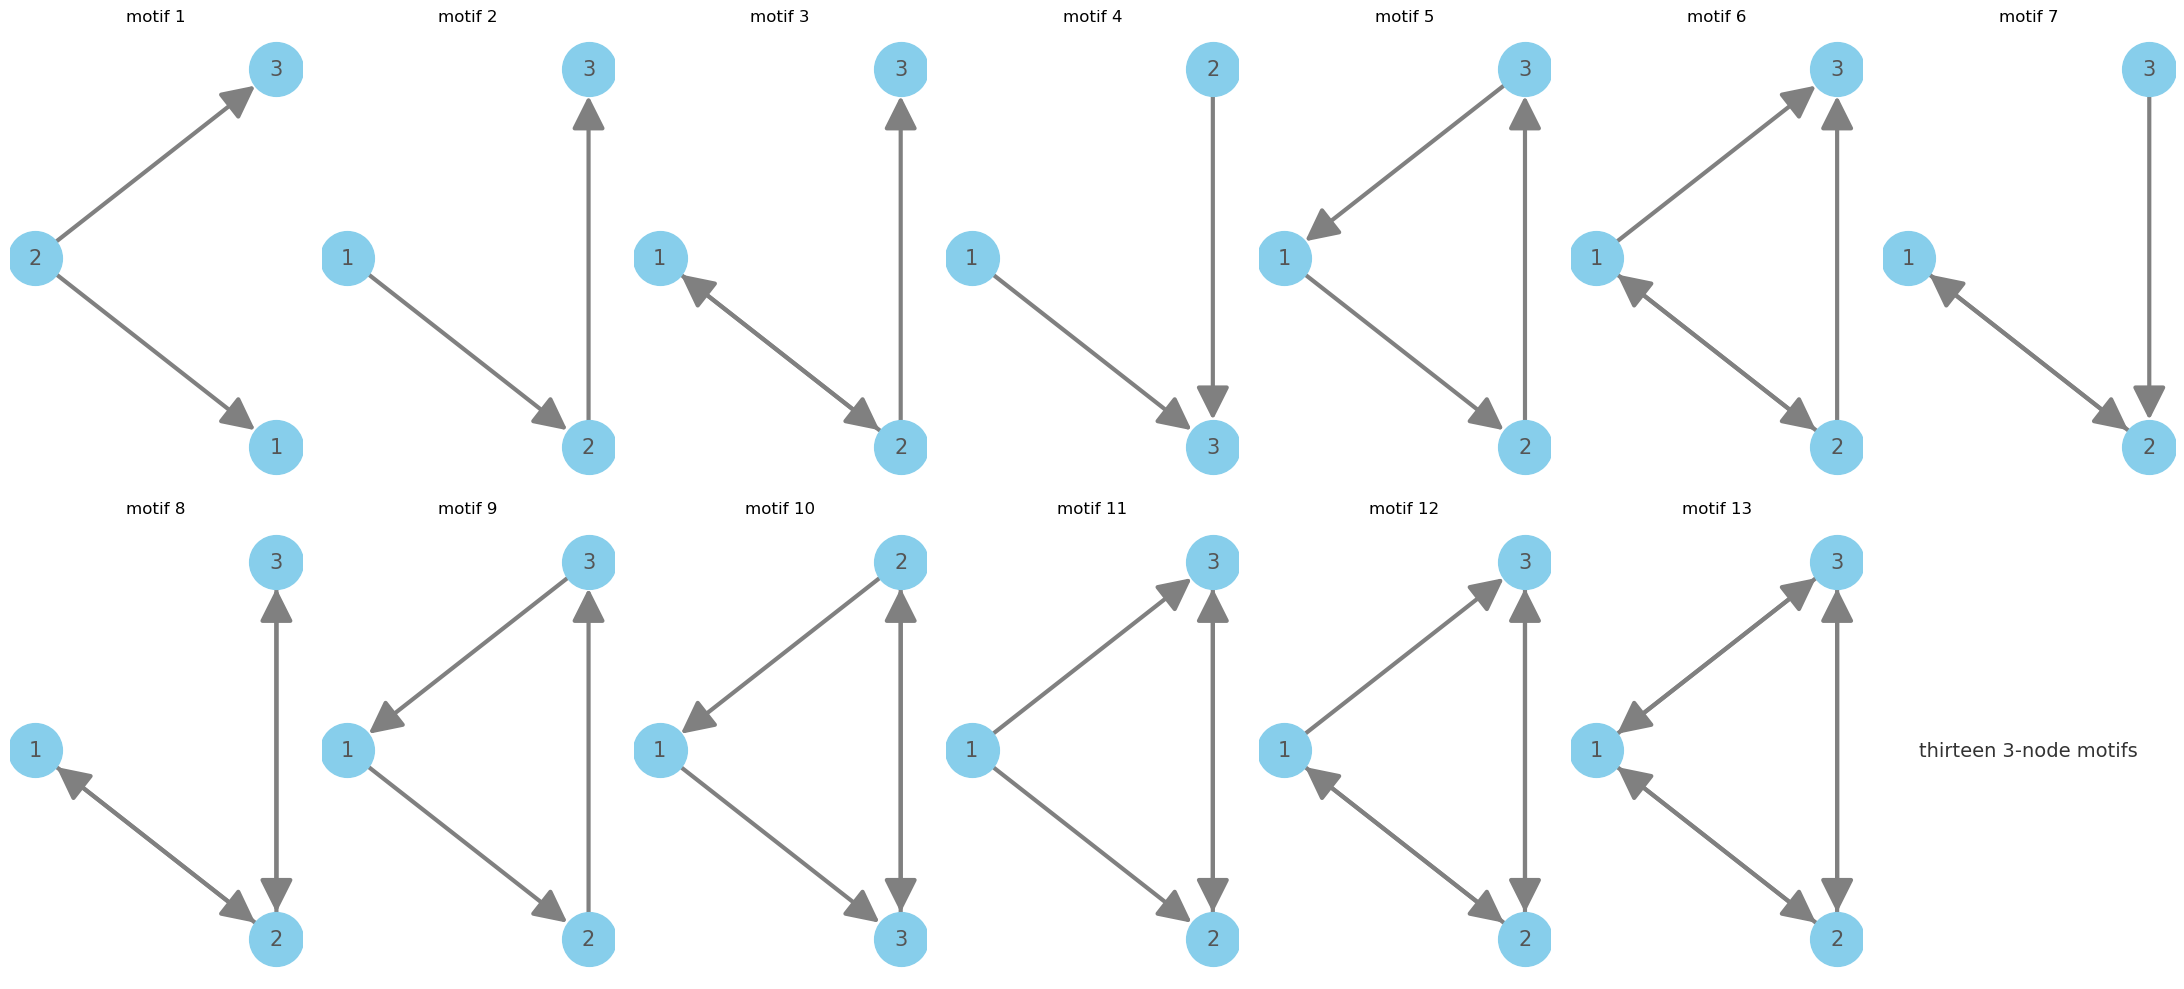

In [4]:
# Create all 13 types of graphs
G1 = nx.DiGraph([(2, 1), (2, 3)])
G2 = nx.DiGraph([(1, 2), (2, 3)])
G3 = nx.DiGraph([(1, 2), (2, 1), (2, 3)])
G4 = nx.DiGraph([(1, 3), (2, 3)])
G5 = nx.DiGraph([(1, 2), (2, 3), (3, 1)])
G6 = nx.DiGraph([(1, 2), (2, 1), (1, 3), (2, 3)])
G7 = nx.DiGraph([(1, 2), (2, 1), (3, 2)])
G8 = nx.DiGraph([(1, 2), (2, 1), (2, 3), (3, 2)])
G9 = nx.DiGraph([(1, 2), (2, 3), (3, 1)])
G10 = nx.DiGraph([(1, 3), (2, 1), (2, 3), (3, 2)])
G11 = nx.DiGraph([(1, 2), (1, 3), (2, 3), (3, 2)])
G12 = nx.DiGraph([(1, 2), (2, 1), (2, 3), (3, 2), (1, 3)])
G13 = nx.DiGraph([(1, 2), (2, 1), (2, 3), (3, 2), (1, 3), (3, 1)])

graphs = [G1, G2, G3, G4, G5, G6, G7, G8, G9, G10, G11, G12, G13]

# Now let's draw them
fig, axs = plt.subplots(2, 7, figsize=(22, 10))

# Set the space between subplots and the top margin
fig.subplots_adjust(hspace=0.5, top=0.96)

for i, graph in enumerate(graphs):
    plt.subplot(2, 7, i+1)
    nx.draw_shell(graph, with_labels=True, edge_color='grey', width=3, arrows=True, node_color='skyblue', arrowsize=50, node_size=1500, font_color='#555555', font_size=15)
    plt.title('motif {}'.format(i+1))
axs[1,6].text(0.5, 0.5, 'thirteen 3-node motifs',
             horizontalalignment='center',
             verticalalignment='center',
             fontsize=14, color='#333333',
             transform=axs[1,6].transAxes)
axs[1,6].axis('off')
    
plt.tight_layout()
plt.show()

Here is a brief interpretation and biological significance of each of these 13 directed graphs or motifs:

G1: **Diverging motif** - The node 2 sends signals to nodes 1 and 3. This pattern can represent a common source or regulator controlling two downstream entities. For example, a transcription factor regulating two different genes.

G2: **Linear motif** - This is a simple signal transduction pathway. Node 1 signals node 2 which then signals node 3. This is a basic feed-forward mechanism seen in many biological pathways.

G3: **Feed-forward Loop** - This motif has a primary feed-forward pattern (1→2→3) with an additional feedback loop (2→1). These types of structures can stabilize signals or create oscillatory behavior, depending on how the feedback is implemented.

G4: **Converging motif** - Nodes 1 and 2 both signal node 3, which could represent multiple signals converging on a single target. This motif is commonly seen in signal integration in neuronal networks and gene regulation.

G5: **Cycle** - Each node signals to the next, forming a cycle (1→2→3→1). This motif can create oscillatory or cyclical behaviors and is seen in various systems, such as metabolic cycles or cell-cycle regulation.

G6: **Bi-Fan motif** - Nodes 1 and 2 both signal nodes 3, with a feedback loop (2→1). The bi-fan motif can be found in many information-processing systems and is known for its signal separation characteristics.

G7: **Feedback Loop** - This motif is similar to G3 but includes a third node receiving signals from the feedback loop. Feedback loops are fundamental motifs seen in many biological systems, including gene regulation and metabolic pathways.

G8: **Fully connected feedback Loop** - All nodes are connected to each other with feedback loops, allowing for a complex interplay of regulatory signals. This motif is also common in biological systems and can provide robustness and stability.

G9: **Cycle** - This is identical to G5. Cycles are a prevalent motif in biological systems, particularly those showing oscillatory behaviors.

G10: **Fully connected with Cycle** - Nodes 1 and 2 signal to each other, and together they signal node 3. This motif can be seen in systems that require a high level of integration of signals and complex behaviors.

G11: **Fully connected Bi-Fan** - All nodes are interconnected in a way that forms two Bi-Fan motifs. This could indicate complex regulatory interactions.

G12: **Fully connected with Feed-Forward Loop** - This motif features multiple feedback and feed-forward loops, suggesting a system with complex regulatory mechanisms.

G13: **Fully Connected** - This motif represents the most interconnected case, with each node sending signals to every other node. Such systems can exhibit complex dynamics and high adaptability.


---

In the context of gene regulatory networks, network motifs can help us understand the basic functional units of gene regulation.

## Network Motifs in E. Coli Transcription Network

["Network Motifs in the Transcriptional Regulation Network of Escherichia coli"](https://www.nature.com/articles/ng881z) by Uri Alon and colleagues focused on the structure and identification of motifs within the transcriptional regulation network of Escherichia coli.

### Motif Discovery

To uncover the inherent structure in the E. coli transcription network, Alon and his team utilized network motif detection algorithms. These algorithms are designed to identify recurring interconnected patterns, termed "network motifs," that appear significantly more often in the network than would be expected in a randomized network with similar properties.

In their comprehensive scan of the E. coli transcription network, three significant network motifs emerged:

1. **Feedforward Loop**: This motif is characterized by a transcription factor X that regulates a second transcription factor Y, and together, X and Y jointly regulate an operon Z. X is known as the 'general transcription factor', Y as the 'specific transcription factor', and Z as the 'effector operon(s)'. The authors identified this motif in **22** different systems within their network database, with ten different general transcription factors.

    In a coherent feedforward loop, the direct effect of the general transcription factor on the effector operons is the same as its net indirect effect through the specific transcription factor. Interestingly, most (85%) of the feedforward loop motifs in the E. coli network were coherent.

2. **Single-Input Module (SIM)**: This motif consists of a set of operons that are controlled by a single transcription factor. All of the operons are under control of the same sign (all positive or all negative) and have no additional transcriptional regulation. The transcription factors controlling SIM motifs are usually autoregulatory.

3. **Dense Overlapping Regulons (DOR)**: The DOR motif is a densely connected layer of interactions between operons and a group of input transcription factors. This motif was found to be much denser than corresponding structures in randomized networks.

These three motifs, which were significantly overrepresented in the E. coli transcriptional regulation network, provide us with an abstracted view of the network's structure. They might serve as basic building blocks or fundamental units of function that have been reused and combined in various ways through the evolutionary process to create the complex gene regulatory networks we see in living organisms today.

These motifs also give us some clues about the possible dynamics of the network, including the temporal and combinatorial aspects of gene regulation. For example, the feedforward loop might function as a kind of signal processing unit, able to generate specific temporal expression programs and respond to fluctuating external signals.

Text(0.5, 1.0, 'Coherent Feedforward Loop')

Text(0.5, 1.0, 'Incoherent Feedforward Loop')

Text(0.5, 1.0, 'Single-Input Module')

Text(0.5, 1.0, 'Dense Overlapping Regulons')

(np.float64(-1.1795920474536667),
 np.float64(0.8899924993933498),
 np.float64(-0.5300031833957662),
 np.float64(0.7727771116854997))

(np.float64(-1.168788469648835),
 np.float64(0.776297704399646),
 np.float64(-0.7717917051008926),
 np.float64(1.1318351082106064))

(np.float64(-0.4988232935817923),
 np.float64(0.8850609915595132),
 np.float64(-1.1743417282506539),
 np.float64(1.2066116574355825))

(np.float64(-1.1917821344527073),
 np.float64(1.0182786530499202),
 np.float64(-0.9497029617549737),
 np.float64(1.1679855219402813))

Text(0.5, 0.98, 'Network motifs in E.coli transcription network')

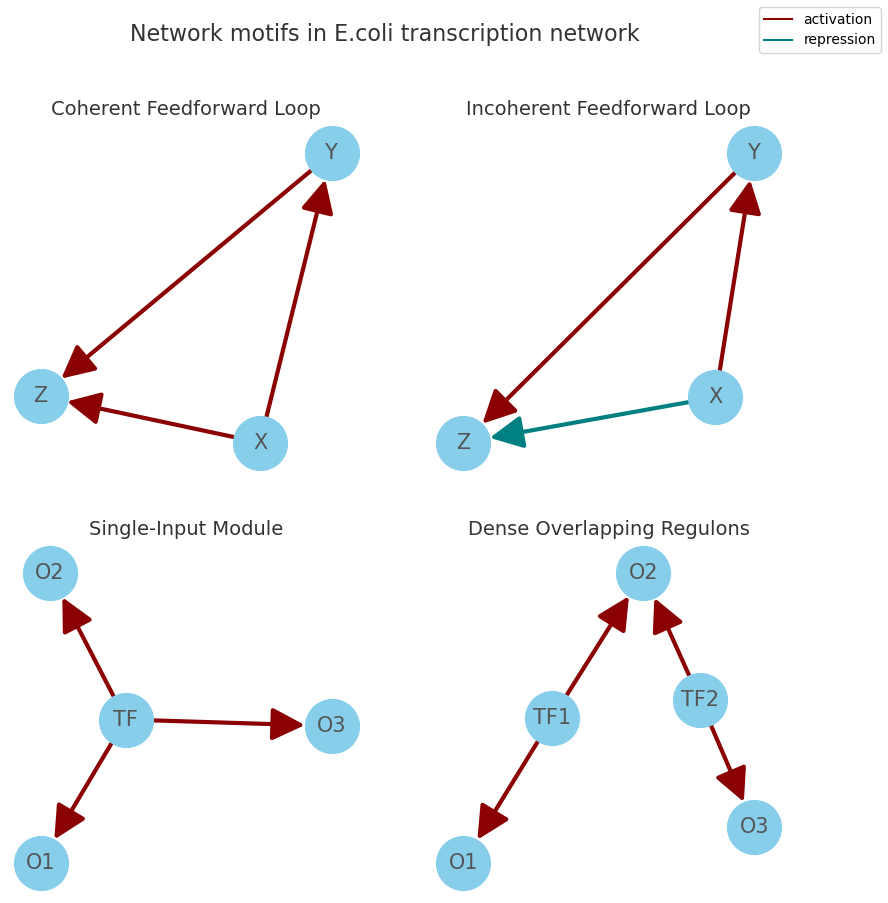

In [5]:
# Create a new figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Define common style parameters
style = {
    "width": 3,
    "arrowsize": 50,
    "node_color": "skyblue",
    "node_size": 1500,
    "font_color": "#555555",
    "font_size": 15,
    "arrows": True
}

# Feedforward Loop (Coherent)
FFC = nx.DiGraph()
FFC.add_edges_from([('X', 'Z'), ('X', 'Y'), ('Y', 'Z')], color='darkred')
edges = FFC.edges()
colors = [FFC[u][v]['color'] for u,v in edges]
nx.draw_networkx(FFC, ax=axs[0, 0], edge_color=colors, **style)
axs[0, 0].set_title('Coherent Feedforward Loop', size=14, color='#333333')

# Feedforward Loop (Incoherent)
FFI = nx.DiGraph()
FFI.add_edges_from([('X', 'Z')], color='teal')  # This is an inhibitory interaction in an incoherent feedforward loop
FFI.add_edges_from([('X', 'Y'), ('Y', 'Z')], color='darkred')  # These are excitatory interactions in an incoherent feedforward loop
edges = FFI.edges()
colors = [FFI[u][v]['color'] for u,v in edges]
nx.draw_networkx(FFI, ax=axs[0, 1], edge_color=colors, **style)
axs[0, 1].set_title('Incoherent Feedforward Loop', size=14, color='#333333')

# Single-Input Module (SIM)
SIM = nx.DiGraph()
SIM.add_edges_from([('TF', 'O1'), ('TF', 'O2'), ('TF', 'O3')], color='darkred')  # All interactions are excitatory in this example
edges = SIM.edges()
colors = [SIM[u][v]['color'] for u,v in edges]
nx.draw_networkx(SIM, ax=axs[1, 0], edge_color=colors, **style)
axs[1, 0].set_title('Single-Input Module', size=14, color='#333333')

# Dense Overlapping Regulons (DORs)
DOR = nx.DiGraph()
DOR.add_edges_from([('TF1', 'O1'), ('TF1', 'O2'), ('TF2', 'O2'), ('TF2', 'O3')], color='darkred')  # All interactions are excitatory in this example
edges = DOR.edges()
colors = [DOR[u][v]['color'] for u,v in edges]
nx.draw_networkx(DOR, ax=axs[1, 1], edge_color=colors, **style)
axs[1, 1].set_title('Dense Overlapping Regulons', size=14, color='#333333')

# Remove axis for each subplot
for ax in axs.flat:
    ax.axis('off')

# Add a common title for the entire figure
fig.suptitle('Network motifs in E.coli transcription network', fontsize=16,color='#333333')

# Create a legend
import matplotlib.lines as mlines
red_line = mlines.Line2D([], [], color='darkred', markersize=15, label='activation')
blue_line = mlines.Line2D([], [], color='teal', markersize=15, label='repression')
fig.legend(handles=[red_line, blue_line], loc='upper right')

plt.show()


## Modeling Dynamics Based on Network Motifs

Understanding the dynamics of signal propagation and transcriptional regulation is a powerful application of network motifs. Each motif in a network can be thought of as a small circuit that processes signals or information in a unique way. By identifying these motifs and understanding their individual behaviors, we can start to piece together the underlying "logic" of complex biological processes such as transcriptional regulation.

For example, let's take one of the three-node motifs from Uri Alon's work:

**Feedforward Loop (FFL)**: In this motif, one transcription factor regulates another, and both jointly regulate a third. Depending on the nature of these regulatory interactions, the FFL can behave like a noise filter, a persistence detector, or a pulse generator. These behaviors can provide stability, enhance responsiveness, or introduce delays in the system, respectively.

To model these dynamics, researchers often use ordinary differential equations (ODEs) to describe the rates of change in the expression levels of genes based on the current state of the system. These models can then be simulated under different conditions to predict the system's behavior.

Another approach is to use Boolean networks or other types of logic models, which can simplify the problem by assuming genes are either "on" or "off" rather than needing to track continuous expression levels.

Both of these methods can offer insights into how signals propagate through a network and how the network as a whole responds to different signals or perturbations. However, it's important to keep in mind that these models are simplifications of reality and may not capture all of the complexity of biological systems. For example, they typically assume that all interactions are instantaneous and deterministic, whereas in reality there can be delays, fluctuations, and stochastic effects to consider.

Text(0.5, 0, 'time')

Text(0, 0.5, 'normalized concentration')

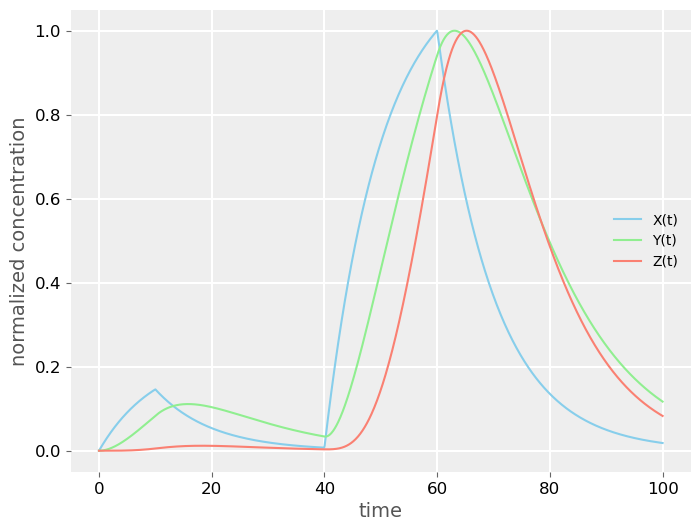

In [6]:
from scipy.integrate import odeint

# Parameters
# First we define the rate constants for the production of X, Y, and Z respectively.
# They control the speed at which each of these components is produced in response to the appropriate signals.
# The higher the value of k, the faster the respective component is produced.
k1 = k2 = k3 = 1.0
# Next we define the rate constants for the degradation of X, Y, and Z respectively.
# They control how quickly each of these components is removed or degraded.
# The higher the value of gamma, the faster the respective component is degraded.
gamma1 = gamma2 = gamma3 = 0.1

# System of ODEs
# This defines the system of Ordinary Differential Equations (ODEs) that describe the dynamics
# of the Feedforward Loop (FFL). The state variable is a list that contains the current levels
# of X, Y, and Z at time t.
def system(state, t):
    X, Y, Z = state
    u = input_signal(t)  # We'll define this function below
    dXdt = k1 * u - gamma1 * X
    dYdt = k2 * X - gamma2 * Y
    dZdt = k3 * X * Y - gamma3 * Z
    return [dXdt, dYdt, dZdt]

# Input signal: a small, short pulse followed by a longer, higher pulse
def input_signal(t):
    if t < 10:
        return 0.1
    elif t < 20:
        return 0
    elif t < 40:
        return 0
    elif t < 60:
        return 0.5
    else:
        return 0

# Initial conditions
initial_state = [0, 0, 0]

# Time points
t = np.linspace(0, 100, 1000)

# Solve the ODE
solution = odeint(system, initial_state, t)

# Normalize the solution
solution_norm = solution / solution.max(axis=0)

# Initiate the plot
fig, ax = plt.subplots(figsize=(8, 6))

# We'll use thin lines and muted colors for the plots.
ax.plot(t, solution_norm[:, 0], label='X(t)', color='skyblue', linewidth=1.5)
ax.plot(t, solution_norm[:, 1], label='Y(t)', color='lightgreen', linewidth=1.5)
ax.plot(t, solution_norm[:, 2], label='Z(t)', color='salmon', linewidth=1.5)

# Remove all border spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Minimal tick marks
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Increase font size and lighten tick labels
ax.tick_params(axis='both', which='major', labelsize=12, color='#666666')

# Set the face color of the plot to a light gray for better contrast
ax.set_facecolor('#EEEEEE')

# Make grid lines lighter and put them behind
ax.grid(color='white', linewidth=1.5)
ax.set_axisbelow(True)

# Remove the legend box, and put the legend in the plot to minimize wasted space
ax.legend(frameon=False, loc='center right')

plt.xlabel('time', fontsize=14, color='#555555')
plt.ylabel('normalized concentration', fontsize=14, color='#555555')

plt.show()


# Interpretation of the Feedforward Loop Dynamics

The simulation above represents the dynamic behavior of a **Coherent Feedforward Loop (C-FFL)**, which is one of the core network motifs discovered in the transcriptional regulation network of *E. coli*. 

In this simulation, we plot over time the concentration of three entities: 

- The general transcription factor **X(t)**
- The specific transcription factor **Y(t)**
- The effector gene or operon **Z(t)** 

We can observe several interesting aspects from the simulation results:

1. **Fast, Transient Response to Short Signals:** In the first peak of the input signal (from time 0 to 10), we see that the general transcription factor X responds quickly. However, since the signal is not sustained, neither the specific transcription factor Y nor the effector gene Z are significantly upregulated.

2. **Pulse Generation and Filtering:** The C-FFL is known for its pulse-generating and filtering characteristics. Here, in response to a short, small amplitude pulse (time 0 to 10), the system effectively ignores the signal. This is an example of how such motifs can help filter out noise in gene regulation.

3. **Response to Sustained Signals:** In contrast to the first peak, the sustained, higher amplitude signal (from time 20 to 50) leads to significant upregulation of both Y and Z, albeit with a delay. This highlights the key role of Y in the system, acting as a gatekeeper for the regulation of Z.

4. **Signal Termination:** Once the signal drops to zero again (at time 50), X, Y and Z all return to their baseline levels, demonstrating the dynamic balance maintained by the C-FFL motif.

By understanding these dynamics, we gain insights into how cells can respond to various environmental signals in a nuanced manner, effectively distinguishing between noise and sustained, meaningful signals.

---

## Challenges of Network Motif Discovery

Since the inital work of Uri Alon and his team in identifying three-node motifs in network structures, further exploration and understanding of network motifs have unveiled some significant challenges in the process of algorithmic motif discovery. 

1. **computational complexity** is a major factor that has made the detection of motifs in large networks a non-trivial task. The computation grows exponentially with the increase in the size of the motif (i.e., the number of nodes involved) and the size of the network. Algorithms employed for detecting motifs have to exhaustively enumerate all possible subgraphs, which becomes computationally intensive and time-consuming for larger motifs and larger networks.

2. **comparison with random networks** in the motif detection process poses its own set of challenges. The idea is to identify subgraphs that appear more frequently in the actual network than in a randomized version of the network. However, generating an appropriate random network is not straightforward. There's a trade-off between generating a random network that maintains some properties of the original network and ensuring the random network is different enough to serve as a valid point of comparison. Additionally, network topology can vary widely across different types of networks (e.g., social networks, biological networks, technological networks), which makes it hard to define a "one-size-fits-all" random network for comparison.

3. It's also important to consider that while these methods can identify motifs that are statistically over-represented, they don't automatically provide insight into the **functional relevance** of these motifs. Even if a particular pattern is common, it doesn't necessarily mean that it plays an important role in the network's behavior. Therefore, further biological experiments or case-specific studies are usually required to validate the significance of the discovered motifs.

---


# **Exploring Modules in Networks**: 
In network science, modules, also known as communities, refer to groups of nodes that are more densely connected to each other than to the rest of the network. In other words, nodes within the same module tend to share more connections with each other than with nodes in different modules. Module detection is an important task in network analysis because it can reveal the underlying structure and organization of the network.

A study that provides a significant example of module detection in a gene co-expression network is the paper "WGCNA: an R package for weighted correlation network analysis" by Langfelder and Horvath. In this paper, the authors use an approach based on weighted correlation network analysis (WGCNA) to identify modules of highly correlated genes in a variety of gene expression datasets.

Remember that you have already used the Louvain algorithm in a previous class, which optimizes modularity in a two-step iterative procedure. It starts by assigning each node to its own community, and then for each node, it evaluates the gain in modularity that would result from removing it from its current community and placing it in a neighboring one. The node is then placed in the community that yields the highest gain in modularity. This procedure is repeated iteratively until no further increase in modularity can be achieved. Finally, each community is replaced by a single node, and the first step is repeated using this condensed network. The process continues until there are no changes in community assignments.

## **MCODE (Molecular Complex Detection)**
An algorithm used in Cytoscape for finding densely connected regions in a network, which often correspond to molecular complexes in protein-protein interaction networks. MCODE uses a heuristic approach to find these densely connected regions, which can be much faster than an exhaustive search for all possible motifs.

The general idea behind MCODE is to assign a "weight" to each node in the network based on its local neighborhood density, and then to "grow" complexes around nodes with high weights. The algorithm proceeds in three main steps:

**Vertex weighting**: Each node in the network is assigned a weight, which is a function of the density of its local neighborhood. This density is calculated as the number of edges in the node's k-neighborhood (i.e., nodes reachable within k steps) divided by the maximum possible number of edges.
**Complex prediction**: Starting from the node with the highest weight, a "seed" complex is grown by adding adjacent nodes that have a weight greater than a given threshold.
**Post-processing**: Overlapping complexes can be merged, and small complexes can be removed based on user-specified parameters.
By focusing on local neighborhoods and using *a heuristic approach*, MCODE can find complexes much more quickly than an exhaustive search. However, this comes at the cost of possibly missing some motifs that would be found by a more thorough search.

While MCODE can be very useful for finding densely connected regions or communities in networks, it is not specifically designed for finding motifs like the three-node motifs discussed above.

## **Tutorial: Using MCODE and Cytoscape for Module Detection in Gene Co-Expression Networks**

**Objective:** In this tutorial, we will load a gene co-expression network into Cytoscape, modify the visual style for better comprehension, and perform module detection using the MCODE algorithm.

**1. Installing MCODE:**

MCODE is a Cytoscape app. To install it:

- Open Cytoscape.
- Go to `Apps > App Manager`.
- In the search box, type "MCODE".
- Click on "MCODE" in the search results, then click "Install".
- For some of you, you may need to download the `.jar` file and install it manually.

**2. Loading the network:**

Assuming you have a network file called `gene_module_5.csv`:

- Go to `File > Import > Network > File...`.
- Navigate to your `.csv` file, and click "Open".
- The default options for loading the network should be correct, but make sure `source` and `target` are properly identified.

**3. Customizing the visual style:**

Make some edits to the visual style enhance the appearance of our network. We'll adjust the edge transparency and, if you wish, make other changes:

- Go to the "Style" tab in the Control Panel on the left.
- Select the style you want to start with before modifications.
- Go to the Edge tab.
- In the list of properties, click on "Edge Transparency".
- Set the value to 50.
- Experiment with other style settings as you like. For instance, you might want to adjust "Node Fill Color" and "Edge Color", or just stick with a predefined style.

**4. Performing MCODE analysis:**

With MCODE installed and our network loaded and styled, we can perform module detection:

- Go to `Apps > MCODE`.
- Click on "Analyze" in the MCODE control panel.
- Explore the parameters. The default parameters work well for most networks, but you might want to adjust these depending on your specific needs. Here, we will just use the defaults.
- Click "Start" to run the analysis.

MCODE will generate a set of clusters, which represent modules in your network. You can explore these clusters through the MCODE Results Panel, and view each one in a new network view.

**5. Select a module for further analysis.**

- In the MCODE tab, scroll through the number of modules identified and select module 10.
- Selecting the module will highlight the nodes in the main network.
- Click on the `New Network from Selection` tab to inspect this module in isolation.
- From the `Node Table`, copy the shared name list into Metascape and run the analysis.
- Based on these results, does it seem like this might be a valid module for further analysis?

**6. Interpretation:**

Interpretation of the modules identified will depend on the biological context. Remember that modules in gene co-expression networks often represent groups of genes involved in the same biological processes. You can explore the functional enrichment of each module (e.g., using Gene Ontology analysis) to gain more insights.

- Select another module from the MCODE list and explore its functional enrichments.
- We will share our findings with the rest of the class.

---


# A (quick/cursory) Introduction to Machine Learning with Networks

In the vast and rapidly evolving field of machine learning, **networks** play a fundamental role in structuring data and algorithms. They allow us to capture and represent complex relationships between various entities. This (all to) brief introduction will describe the concept of machine learning with networks and particularly focus on a popular type of network known as the **Neural Network**.

## Neural Networks - The Backbone of Machine Learning that also gets "Deep"

A type of network that has garnered significant attention in machine learning is the **Neural Network**. Neural networks form the backbone of what we commonly refer to as **deep learning**.

### How does a Neural Network work?

A neural network is inspired by the human brain's biological network of neurons. In a nutshell, it consists of numerous interconnected processing nodes, referred to as *neurons* or *nodes*. These nodes are organized into layers:

1. **Input Layer**: This layer receives the raw input data, comparable to our sensory data like sight or touch. 
    ***Input Nodes***: The number of input nodes in a neural network typically corresponds to the dimensionality of your input data. For instance, if you were considering the presence or absence of 20,000 genes in your samples, you would have 20,000 input nodes, one for each gene. If you were considering more detailed features, like specific mutations within those genes or expression levels, then the number of input nodes would increase accordingly.

2. **Hidden Layer(s)**: These are layers of nodes between the input and output layers. These nodes perform computations and transform the inputs into something the output layer can use. There can be multiple hidden layers in a neural network, which is where the term "deep" in deep learning comes from.
    ***Hidden Nodes***: The number of nodes in the hidden layers is a more arbitrary choice and can significantly impact the learning capability of the network. Too few nodes might lead to underfitting (the model doesn't learn the underlying patterns), while too many might lead to overfitting (the model learns the noise in the data along with the patterns). There's no rule stating you must have more hidden nodes than input or output nodes. In practice, the optimal number often needs to be determined via trial and error or using techniques like cross-validation.

3. **Output Layer**: This layer produces the final result, or the prediction, of the neural network.
    ***Output Nodes***: The number of output nodes is generally determined by the task at hand. For binary classification, a single output node is often used. For multi-class classification problems, you would typically have one output node for each class. For regression tasks, you typically have a single output node.

The edges in a neural network, which connect the nodes in various layers, represent weights or parameters that the network learns during the training phase. These weights determine the importance or influence of a node's input on the output.

Text(0.5, 1.0, 'neural network architecture')

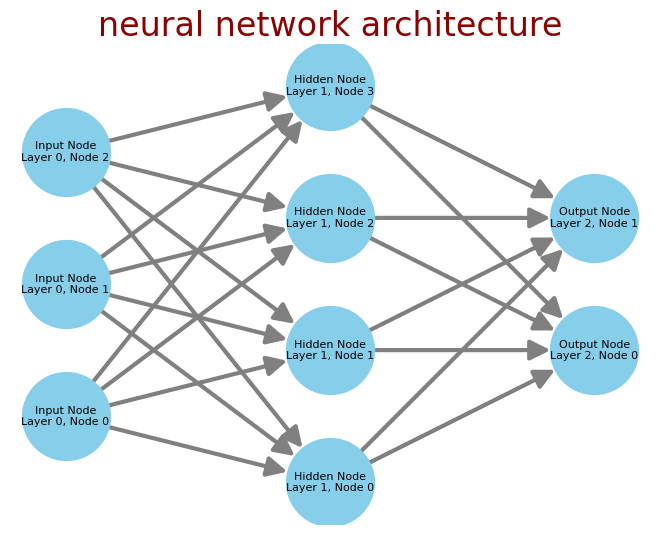

In [7]:
style = {
    "width": 3,
    "arrowsize": 30,
    "node_color": "skyblue",
    "node_size": 4000,
    "font_color": "#555555",
    "font_size": 15,
    "arrows": True,
    "edge_color": "grey"
}

def draw_neural_net(layer_sizes):
    G = nx.DiGraph()
    pos = {}
    labels = {}

    max_layer_size = max(layer_sizes)
    
    for i, layer_size in enumerate(layer_sizes):
        for j in range(layer_size):
            G.add_node((i, j))
            offset = (max_layer_size - layer_size) / 2.0  # Calculate the offset required to center the nodes
            pos[(i, j)] = (i, -j - layer_size/2.0 + offset)
            labels[(i, j)] = f"{'Input' if i == 0 else ('Output' if i == len(layer_sizes) - 1 else 'Hidden')} Node\nLayer {i}, Node {j}"
        if i > 0:
            for j in range(layer_sizes[i - 1]):
                for k in range(layer_sizes[i]):
                    G.add_edge((i - 1, j), (i, k))
        # Calculate position of each node in a centered and aligned way
    pos = {(layer, node): (layer, -layer_sizes[layer] / 2. + node) for layer in range(len(layer_sizes)) for node in range(layer_sizes[layer])}
    nx.draw(G, pos, **style, with_labels=False)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, verticalalignment='center', horizontalalignment='center')

layer_sizes = [3, 4, 2]  # For example, 3 input nodes, 4 hidden nodes, and 2 output nodes
draw_neural_net(layer_sizes)
plt.title("neural network architecture", size=24, color='darkred')
plt.show()

Text(0.5, 1.0, "A 'deep' neural network architecture")

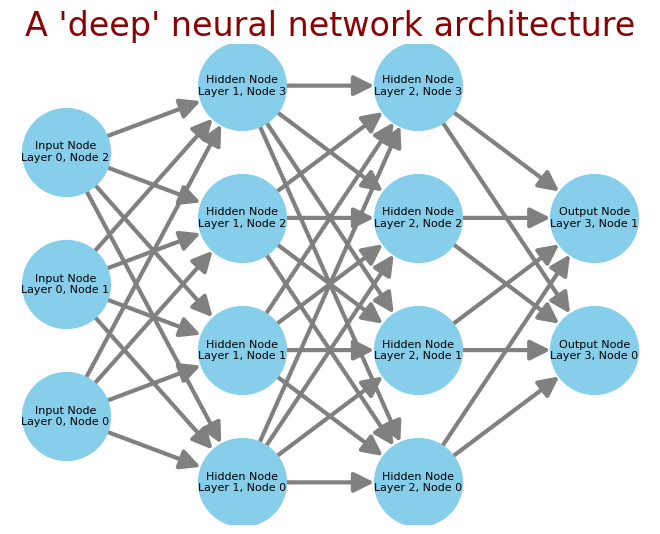

In [8]:
layer_sizes = [3, 4, 4, 2]  # 3 input nodes, two hidden layers with 4 nodes each, and 2 output nodes
draw_neural_net(layer_sizes)
plt.title("A 'deep' neural network architecture",size=24, color='darkred')
plt.show()

Keep in mind, this is a highly simplified view of what neural networks and deep learning involve. The complexity grows with the inclusion of **convolutional** layers (used in image processing), **recurrent** layers (for sequence data), and various other architectures suited for different types of data and tasks.

Even though it may sound complex, the beauty of machine learning with networks, and specifically with neural networks, is that it all boils down to learning the right weights (parameters) that minimize the error in our predictions. This concept has revolutionized the way we think about and work with data, leading to breakthroughs in countless applications from computer vision and natural language processing to drug discovery and enhancements in primary healthcare. 

## A simple illustration of a neural network

 Let's illustrate a very basic example of a neural network's operation using a simple logic gate, which has some analogy in biology. An `OR gate` can be seen as a basic neuron that fires or activates when any of its inputs are on. This can be used as an analogy for genes being activated or expressed under certain conditions.

Text(0.5, 1.0, 'an `OR` gate')

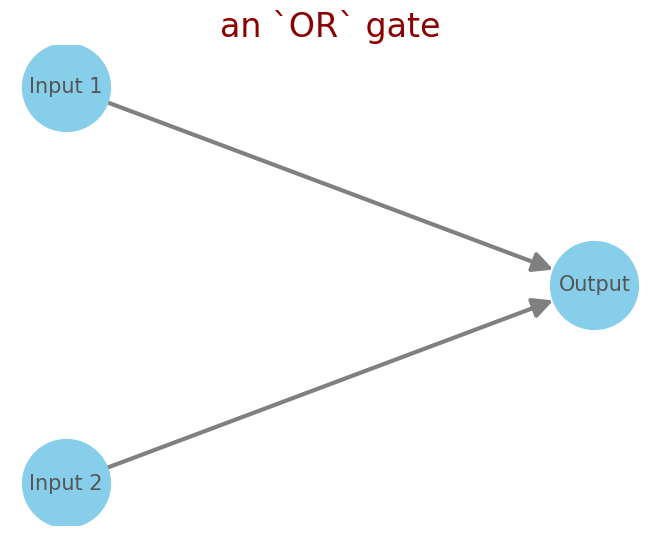

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the node and edge styles
style = {
    "node_size": 4000,
    "node_color": 'skyblue',
    "width": 3,
    "arrowsize": 30,
    "edge_color": "grey",
    "font_color": "#555555",
    "font_size": 15,
}

# Create the graph
G = nx.DiGraph()

# Add the nodes (inputs and output)
G.add_node('Input 1')
G.add_node('Input 2')
G.add_node('Output')

# Add the edges (representing the weights)
G.add_edge('Input 1', 'Output', weight=1)
G.add_edge('Input 2', 'Output', weight=1)

# Define the positions for all nodes
pos = {'Input 1': [0, 1], 'Input 2': [0, 0], 'Output': [1, 0.5]}  

# Draw the graph using nx.draw() instead of drawing edges and labels separately
nx.draw(G, pos, with_labels=True, **style)

plt.title("an `OR` gate", size=24, color='darkred')

plt.show()


Here's this simple `OR gate`, implemented as a one-layer neural network

In [10]:
import numpy as np

# OR gate inputs and outputs.
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # inputs
Y = np.array([[0], [1], [1], [1]])  # outputs

# The neuron weights and bias.
weights = np.array([[1.0], [1.0]])
bias = np.array([-0.5])

# This is a single-layer neural network, so the output is just a weighted sum of inputs plus the bias.
output = np.dot(X, weights) + bias

# The activation function: convert the output into a binary 0 or 1.
# We use the Heaviside step function as an activation function here to simulate a biological neuron firing.
activation_function = np.vectorize(lambda x: 1 if x > 0 else 0)
#  Y_hat is a commonly used symbol that represents the predicted values of a model.
Y_hat = activation_function(output)

print("The output of the neural network is:")
print(Y_hat)


The output of the neural network is:
[[0]
 [1]
 [1]
 [1]]


In the provided code, a single-layer neural network has been built to implement the logical OR gate operation.

First, let's look at the OR gate operation:

| Input 1 | Input 2 | Output |
|---------|---------|--------|
|    0    |    0    |   0    |
|    0    |    1    |   1    |
|    1    |    0    |   1    |
|    1    |    1    |   1    |

If either or both of the inputs are 1, the output is 1. Otherwise, the output is 0.

This is exactly what the code simulates:

1. `X` represents the inputs to the OR gate, and `Y` represents the expected outputs.

2. The weights of the neural network are represented by `weights`, which in this case are both 1. The `bias` is -0.5.

3. The variable `output` is the weighted sum of the inputs plus the bias. This is a basic operation in a neural network where each input is multiplied by a corresponding weight, and all these products are then summed together and the bias is added. This is what `np.dot(X, weights) + bias` does.

4. The activation function is a Heaviside step function, which outputs a 1 if the input is greater than 0, and 0 otherwise. This models the firing of a biological neuron.

5. `Y_hat` is the output of the neural network after applying the activation function. It correctly represents the outputs of an OR gate for the given inputs.

So this neural network correctly models an OR gate using a single layer with two inputs and one output, and you can see this from the `Y_hat` which matches the expected `Y` exactly.

---

Now that we have a basic understanding of a simple-layer neural network, let's add just a little more complexity:

## Introducing the XOR problem.

`XOR`, or "exclusive or", is a logical operation that outputs true only when the number of true inputs is odd. An `XOR` gate is a digital logic gate that gives a true (1) output when the number of true inputs is odd. For two inputs, this means the output is true if exactly one of the inputs is true, and false otherwise.

Here's the truth table for XOR:

| Input 1 | Input 2 | Output |
|---------|---------|--------|
|    0    |    0    |   0    |
|    0    |    1    |   1    |
|    1    |    0    |   1    |
|    1    |    1    |   0    |

`XOR` can't be solved by a single-layer perceptron like our previous `OR` gate. This is because `XOR` is not a linearly separable problem. This essentially means there's no straight line that can separate the inputs that should output 1 from those that should output 0.

So, to solve this, we will need to use a multi-layer perceptron (MLP) -- that is, a neural network with one or more hidden layers.

First, let's visualize this `XOR` neural network with `networkx`.

Text(0.5, 1.0, 'an `XOR` gate')

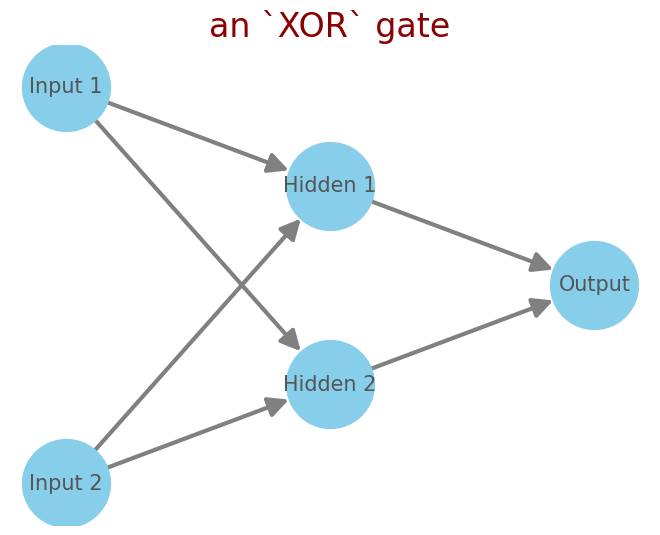

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# Define the node and edge styles
style = {
    "node_size": 4000,
    "node_color": 'skyblue',
    "width": 3,
    "arrowsize": 30,
    "edge_color": "grey",
    "font_color": "#555555",
    "font_size": 15,
}

# Create the graph
G = nx.DiGraph()

# Add the nodes. For XOR, we need a hidden layer, so we add 2 hidden nodes.
G.add_node('Input 1')
G.add_node('Input 2')
G.add_node('Hidden 1')
G.add_node('Hidden 2')
G.add_node('Output')

# Add the edges (representing the weights)
G.add_edge('Input 1', 'Hidden 1')
G.add_edge('Input 1', 'Hidden 2')
G.add_edge('Input 2', 'Hidden 1')
G.add_edge('Input 2', 'Hidden 2')
G.add_edge('Hidden 1', 'Output')
G.add_edge('Hidden 2', 'Output')

# Define the positions for all nodes
pos = {'Input 1': [0, 1], 
       'Input 2': [0, 0], 
       'Hidden 1': [0.5, 0.75], 
       'Hidden 2': [0.5, 0.25], 
       'Output': [1, 0.5]}  

# Draw the graph using nx.draw() instead of drawing edges and labels separately
nx.draw(G, pos, with_labels=True, **style)

plt.title("an `XOR` gate", size=24, color='darkred')

plt.show()


In the `XOR` logic gate, we have 4 combinations of inputs (00, 01, 10, 11). However, unlike an `OR` gate, an `XOR` gate returns 1 only when exactly one of the inputs is 1.

To solve this problem using a neural network, we'll use a structure similar to the one to our network visualization above, with an input layer, one hidden layer, and an output layer.

Before we proceed, let's clarify a couple of things:

**Weights and Biases**: In our network, the information moves from the input nodes, through the hidden nodes, and finally to the output node. The importance of each input is controlled by a factor called the 'weight'. We also add a 'bias' to control how easy it is for the neuron to fire.
**Activation function**: This is a function that decides whether a neuron should be activated or not, by calculating a weighted sum and further adding bias. The purpose of the activation function is to introduce non-linearity into the output of a neuron. We'll be using the sigmoid function as our activation function.
**Backpropagation and Gradient Descent**: These are methods used to adjust the weights and biases based on the error of the output. *Backpropagation* is used to calculate the error contribution of each neuron after a batch of data is processed. It’s a means of using the final error of the system to distribute an error to all contributing parts. *Gradient descent* is an iterative optimization algorithm for finding the minimum of a function; here it is used to minimize the error function by iteratively moving in the direction of steepest descent.

Now let's proceed with our code:

The `NeuralNetwork` class has two main parts: `feedforward` and `backprop`.

The `feedforward` method calculates the predicted output (`self.output`). It first calculates the dot product of inputs and `weights1`, and applies the sigmoid function. The output of this operation is stored in `self.layer1`. This output is then used to compute the final output. The dot product of `self.layer1` and `weights2` is computed and the sigmoid function is applied again.

The `backprop` method calculates the error in the output and adjusts `weights1` and `weights2` accordingly to minimize the error. The adjustment is proportional to the rate of change of error with respect to weights, which is calculated using the chain rule for derivatives.

The `weights1` and `weights2` are updated in the direction in which the error is decreasing (which is calculated by taking derivatives).

The loop at the end of the script runs the `feedforward` and `backprop` methods 1500 times. The more iterations, the better the network will learn to correctly predict the output.

Finally, `print(nn.output)` will print the output of the network after training, which should closely resemble the true outputs `[[0], [1], [1], [0]]`.

In [12]:
import numpy as np

# sigmoid function
def sigmoid(x):
    return 1.0/(1+ np.exp(-x))

# derivative of sigmoid function
def sigmoid_derivative(x):
    return x * (1.0 - x)

class NeuralNetwork:
    def __init__(self, x, y):
        self.input      = x
        self.weights1   = np.random.rand(self.input.shape[1],4) 
        self.weights2   = np.random.rand(4,1)                 
        self.y          = y
        self.output     = np.zeros(self.y.shape)

    def feedforward(self):
        self.layer1 = sigmoid(np.dot(self.input, self.weights1))
        self.output = sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
        # application of the chain rule to find derivative of the loss function with respect to weights2 and weights1
        d_weights2 = np.dot(self.layer1.T, (2*(self.y - self.output) * sigmoid_derivative(self.output)))
        d_weights1 = np.dot(self.input.T,  (np.dot(2*(self.y - self.output) * sigmoid_derivative(self.output), self.weights2.T) * sigmoid_derivative(self.layer1)))

        # update the weights with the derivative (slope) of the loss function
        self.weights1 += d_weights1
        self.weights2 += d_weights2

# Inputs and corresponding XOR outputs
inputs = np.array([[0,0],[0,1],[1,0],[1,1]])
outputs = np.array([[0],[1],[1],[0]])

nn = NeuralNetwork(inputs, outputs)

for i in range(1500):
    nn.feedforward()
    nn.backprop()
print("The output of the neural network is:")
print(nn.output)


The output of the neural network is:
[[0.04407594]
 [0.9635991 ]
 [0.9628343 ]
 [0.03192677]]


How should we interpret these results?

The output of the neural network represents the predictions for the XOR operation. The inputs were:
```
[[0,0],
 [0,1],
 [1,0],
 [1,1]]
```
Corresponding to these inputs, the XOR operation should give the outputs `[0, 1, 1, 0]` respectively.

After training, the neural network gives outputs that look more like:
```
[[0.05213545],
 [0.96593344],
 [0.96224989],
 [0.02237176]]
```
These values are close to `[0, 1, 1, 0]`, but they're not exact because the output of our network is continuous, not discrete. This is due to the sigmoid activation function which we used in our model. The sigmoid function returns a continuous value between 0 and 1, which can be thought of as a probability.

We can interpret these continuous outputs as follows:

- For the input `[0,0]`, the ideal output is `0`. The network predicts `0.05213545`, which is very close to `0`.
- For the input `[0,1]`, the ideal output is `1`. The network predicts `0.96593344`, which is very close to `1`.
- For the input `[1,0]`, the ideal output is `1`. The network predicts `0.96224989`, which is also very close to `1`.
- For the input `[1,1]`, the ideal output is `0`. The network predicts `0.02237176`, which is very close to `0`.

So, the network is predicting the XOR operation correctly for the provided inputs. This indicates that the training was successful: the network learned to approximate the XOR function.

For practical applications where you need a binary output, you could round these values to get `[0, 1, 1, 0]`:

`rounded_output = np.round(nn.output)`

`print(rounded_output)`

Doing this would print:
```
[[0.],
 [1.],
 [1.],
 [0.]]
```
which matches the expected output of the XOR operation exactly.

## Conclusion:

That's a wrap! I hope you have enjoyed this introduction to networks. You've made significant strides in understanding the fundamental concepts of network biology, from the creation and annotation of biological networks, exploring network properties and models, to delving into network motifs, modules, and applications of machine learning to networks.

Networks are an incredibly powerful tool for studying complex biological systems and you are now equipped with knowledge and skills to make your own explorations in this field. Whether it's gene co-expression networks, protein-protein interaction networks, or any other complex network you might encounter, the concepts you've learned in these lectures will help you navigate and interpret these systems with a higher degree of understanding.

Remember that this is just the beginning of your journey. There are many more complex topics and advanced techniques to learn as you delve deeper into the field.

## Additional Resources:

Here are some resources that can help you to expand your knowledge and understanding:

1. **Book**: 
    - "Network Science" by Albert-László Barabási. A comprehensive introduction to the modern field of network science.
    - "An Introduction to Systems Biology: Design Principles of Biological Circuits" by Uri Alon. This book provides an introduction to systems biology with a focus on the design principles of biological circuits, making it a great resource for understanding the mathematical modeling used in systems biology.

2. **Online Tutorials and Documentation**:
    - [NetworkX Documentation](https://networkx.org/documentation/stable/): An excellent resource for learning more about the NetworkX library and network analysis in Python.
    - [SciKit-Learn Documentation](https://scikit-learn.org/stable/): A great resource for machine learning in Python, including numerous examples and tutorials.
    - TensorFlow's Tutorial on Neural Networks: TensorFlow is one of the most popular libraries for implementing machine learning and deep learning algorithms. Their tutorials are well-structured and filled with examples.

    Link: [https://www.tensorflow.org/tutorials/quickstart/beginner](https://www.tensorflow.org/tutorials/quickstart/beginner)
    - PyTorch's Tutorial on Neural Networks**: PyTorch is another popular library for machine learning and deep learning. Their tutorials are highly recommended for their readability and ease of understanding.

    Link: [https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html](https://pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial.html)